# Dask DataFrame

Материалы:
* Макрушин С.В. Лекция 13: Dask DataFrame
* https://docs.dask.org/en/latest/dataframe.html
* JESSE C. DANIEL. Data Science with Python and Dask.

## Задачи для совместного разбора

In [87]:
import dask.dataframe as dd
import pandas as pd
import dask.bag as db
import json
import dask

import re
from datetime import datetime

1. Считать данные из файлов в каталоге `accounts`. Содержат ли какие-либо из столбцов пропуски?

In [2]:
def download_file_url(file_id: str):
    return f'https://drive.google.com/uc?id={file_id}'

files = ['179zNWfu6MaBAklgyQd1I9LWIB-m2mukd', '1D0B-o59Q57x_eckjq3tGcgCAL0LSV9Sf', '1kDPmHtaB0KSxCT014i3jX-noc6Rd70SF']
links = list(map(download_file_url, files))

In [43]:
df = dd.read_csv(links, dtype={'amount': 'float64'})
df

,id,names,amount
npartitions=3,,,
,int64,string,float64
,...,...,...
,...,...,...
,...,...,...


In [44]:
df.head()

,id,names,amount
0,39,Victor,205.0
1,289,Hannah,87.0
2,234,Victor,1820.0
3,155,Ray,-600.0
4,266,Ray,572.0


In [5]:
df.isna().any().compute()

,0
id,False
names,False
amount,True


Столбец amount содержит пропущенные значения

In [45]:
df = df.dropna(subset='amount')

In [46]:
df.isna().any().compute()

,0
id,False
names,False
amount,False


In [8]:
df.head()

,id,names,amount
0,39,Victor,205.0
1,289,Hannah,87.0
2,234,Victor,1820.0
3,155,Ray,-600.0
4,266,Ray,572.0


2. Подсчитать количество раз, которое то или иное имя встретилось в выборке. Вывести самое часто встречающееся имя.

In [9]:
names = df.names.value_counts().compute()
names

,count
names,
Norbert,188147
Alice,185892
George,183249
Tim,162432
Bob,157065
Michael,148372
Ingrid,132067
Oliver,121907
Quinn,118071


In [10]:
names.nlargest(1)

,count
names,
Norbert,188147


3. Создать новую колонку, которая является результатом от деления значения `amount` нацело на 100, если `amount` > 100, и нулём в противном случае.

In [49]:
df['new_amount'] = df['amount']

In [50]:
df.head()

,id,names,amount,new_amount
0,39,Victor,205.0,205.0
1,289,Hannah,87.0,87.0
2,234,Victor,1820.0,1820.0
3,155,Ray,-600.0,-600.0
4,266,Ray,572.0,572.0


In [51]:
df.new_amount = df.new_amount.mask(df.new_amount <= 100, 0)

In [52]:
df.head()

,id,names,amount,new_amount
0,39,Victor,205.0,205.0
1,289,Hannah,87.0,0.0
2,234,Victor,1820.0,1820.0
3,155,Ray,-600.0,0.0
4,266,Ray,572.0,572.0


In [53]:
df['new_amount'] = df['new_amount'] // 100
df.head()

,id,names,amount,new_amount
0,39,Victor,205.0,2.0
1,289,Hannah,87.0,0.0
2,234,Victor,1820.0,18.0
3,155,Ray,-600.0,0.0
4,266,Ray,572.0,5.0


## Лабораторная работа 13

In [55]:
files = [
    '1Dmm0RDxVA3yUsG79HlApY9UOK3bNaDUU',
    '1FGhUcm7qArXUTHVJYdUSItT-YzRlH-o9',
    '1Axl2IeUPJZv_5p36CmXy1YaKKIaEEW15',
    '1ZeKDpWFY3TuFxHG4RAusjUwM_En58sGY',
    '1d49QnHE0bFvVV4Xbi7OhG9ABzhC4sAwx',
    '193BX_lYvqDLWw6x2JoovQly_gpKJhFiW',
    '18RgvmcuugcL6Igh8FaAQ3IHJUDxpXunn',
    '19-2vXq9GqKefRmsp2XDna2eIrbGaMtwt'
]
links = list(map(download_file_url, files))

1. В архиве `recipes_full.zip` находятся файлы, содержащие информацию об рецептах блюд. Загрузите данные из файлов этого архива в виде `dd.DataFrame` с названием `recipes`. Укажите, что в столбце `submitted` содержатся даты.

In [ ]:
df = dd.read_csv(links, parse_dates=['submitted'])

2. Выведите метаинформацию о таблице: `npartitions` и типы столбцов.

In [58]:
df

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
npartitions=8,,,,,,,,
,int64,string,int64,int64,datetime64[ns],int64,string,int64
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


3. Выведите на экран 5 первых строк таблицы. Выведите на экран 5 последних строк таблицы. В случае сообщения об ошибки объясните причину и исправьте ошибку.

In [59]:
df.head()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,683970,vant ivoire mickies nothing,33,803776,2019-08-22,4,pat and gina neely and their family own and op...,9
1,1089012,kremsils mariposa baccala cookies class borage...,23,51579,2013-03-02,1,"a light, tasty and easy to put together chicke...",5
2,1428572,tania lander,0,68884,1980-11-09,1,a delicious melt in your mouth appetizer. for ...,5
3,1400250,heloise milli asher doogh zojirushi,24,678862,2018-04-29,3,delicious cream cheese and peach filled cresce...,1
4,387709,nutty chocolate chunk cookies,47,489552,2009-08-31,8,everyone loves these buttery cookies chock ful...,10


In [60]:
df.tail()

ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`.

+---------+---------+----------+
| Column  | Found   | Expected |
+---------+---------+----------+
| minutes | float64 | int64    |
| n_steps | float64 | int64    |
+---------+---------+----------+

Usually this is due to dask's dtype inference failing, and
*may* be fixed by specifying dtypes manually by adding:

dtype={'minutes': 'float64',
       'n_steps': 'float64'}

to the call to `read_csv`/`read_table`.

Alternatively, provide `assume_missing=True` to interpret
all unspecified integer columns as floats.

Ошибка возникла из-за присутствия пропущенных значений в столбцах minutes и n_steps, которые были интерпретированы как int64. Чтобы работать с пропущенными значениями эти столбцы должны иметь тип float

In [61]:
df = dd.read_csv(links, assume_missing=True, parse_dates=['submitted'])

In [62]:
df.head()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,683970.0,vant ivoire mickies nothing,33.0,803776.0,2019-08-22,4.0,pat and gina neely and their family own and op...,9.0
1,1089012.0,kremsils mariposa baccala cookies class borage...,23.0,51579.0,2013-03-02,1.0,"a light, tasty and easy to put together chicke...",5.0
2,1428572.0,tania lander,0.0,68884.0,1980-11-09,1.0,a delicious melt in your mouth appetizer. for ...,5.0
3,1400250.0,heloise milli asher doogh zojirushi,24.0,678862.0,2018-04-29,3.0,delicious cream cheese and peach filled cresce...,1.0
4,387709.0,nutty chocolate chunk cookies,47.0,489552.0,2009-08-31,8.0,everyone loves these buttery cookies chock ful...,10.0


In [63]:
df.tail()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
278949,1029131.0,tuti waffle snackies steakhouse,19.0,171345.0,1973-10-18,4.0,"according to a providence journal article, ama...",4.0
278950,1700703.0,noelias cheats crocante fleisch zitumbuwa,1.0,30228.0,2007-07-01,6.0,if possible sauté the onions and garlic in abo...,1.0
278951,1910650.0,rubbed restuffed pelmeni bedouin flavourful,60.0,591905.0,2009-09-26,3.0,another great recipe to add to the growing swe...,2.0
278952,713836.0,stems polpettine peezi,NaN,357389.0,2003-09-30,4.0,adapted from top secret recipes. love this!,9.0
278953,660699.0,clementines,64.0,29196.0,1973-06-03,6.0,this would make a great start to your holiday ...,8.0


4. Посчитайте, сколько строк содержит каждый из блоков

In [65]:
df.map_partitions(len).compute()

,0
0,278955
1,278955
2,278955
3,278955
4,278955
5,278954
6,278954
7,278954


5. Найдите максимум в столбце `n_steps`. Визуализируйте граф вычислений для этой задачи. Прокомментируйте логику работы `dask` в этом случае.

In [66]:
find_max = df.n_steps.max()
find_max.compute()

145.0

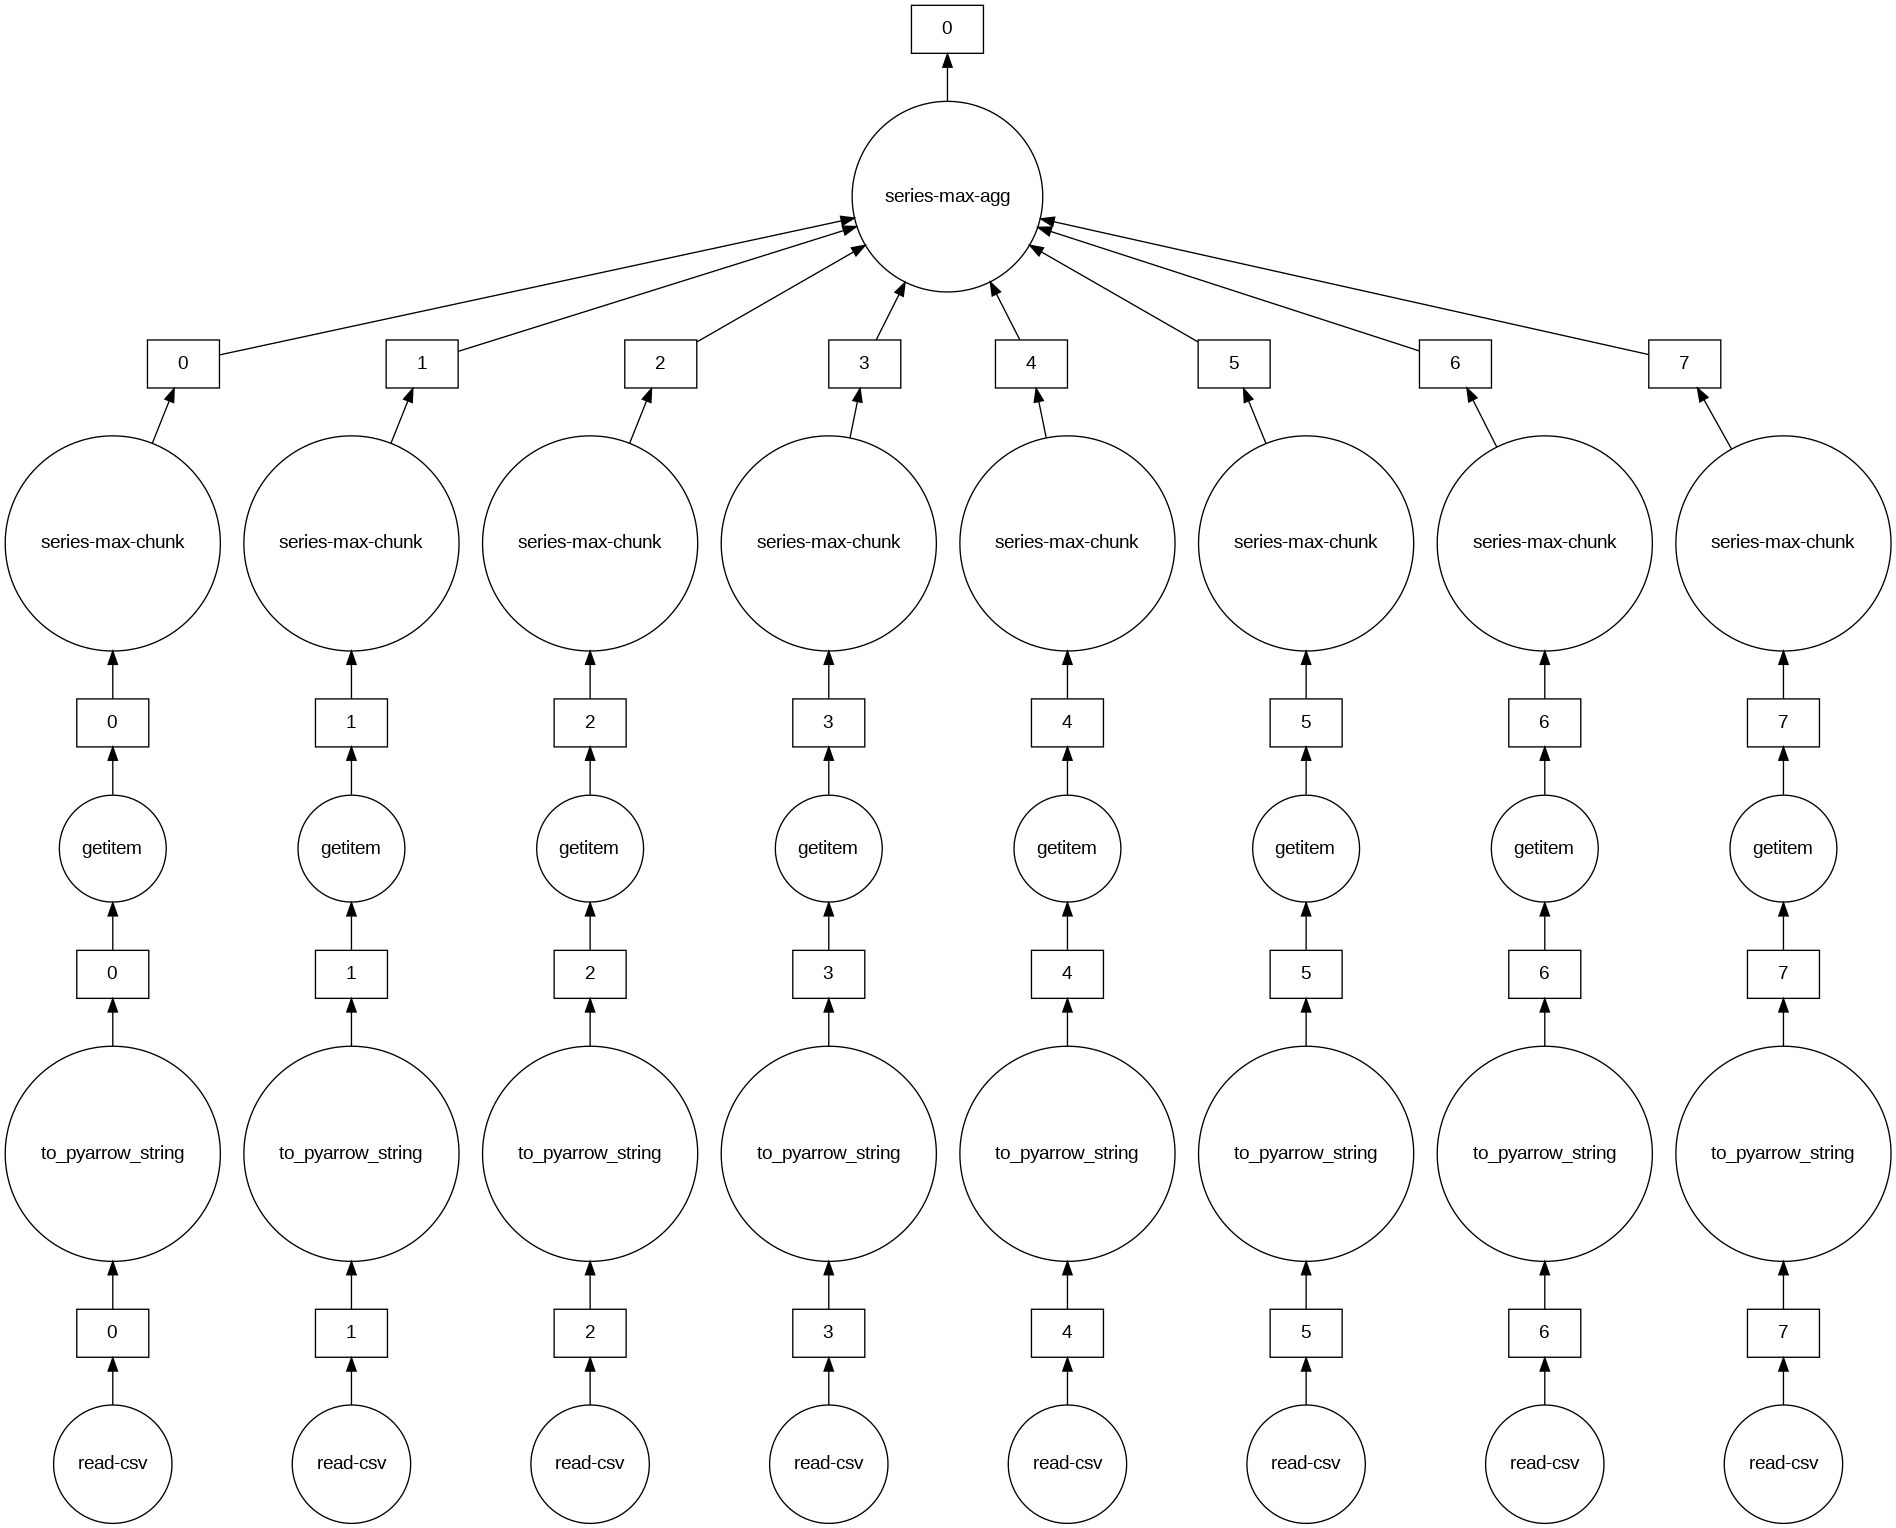

In [67]:
find_max.visualize()

Даск параллельно находит максимум по каждому из блоков, после чего берет максимальное полученное значение

6. Посчитайте количество отзывов с группировкой по месяцам добавления отзыва в базу.

In [198]:
df['submitted_month'] = df['submitted'].dt.to_period('M')

In [199]:
recipies_count_per_month = df.groupby('submitted_month').count()['id'].compute()
recipies_count_per_month

,id
submitted_month,
1970-01,3306
1970-02,2943
1970-03,3324
1970-04,3245
1970-05,3284
...,...
2021-04,3139
2021-05,3223
2021-06,3128


7. Считайте файлы из архива `reviews_full.zip` (__ЛР12__) в виде `dask.bag`. Пользуясь результатом лабораторной работы 12, рассчитайте среднее значение оценок отзывов с группировкой по месяцам. После завершения всех вычислений преобразуйте результат к `pd.Series`.

In [78]:
%cd /content/drive/MyDrive/ФУППРФ/5 семестр/Технологии обработки больших данных/data/12

/content/drive/MyDrive/ФУППРФ/5 семестр/Технологии обработки больших данных/data/12


In [194]:
def parse_json(tup):
    json_, file_name = tup
    d = json.loads(json_)
    d['rating'] = int(re.findall(r'reviews_(\d)+', file_name)[0])
    return d
records = db.read_text('reviews_*.json', include_path=True)
records

dask.bag<bag-from-delayed, npartitions=5>

In [195]:
records_parsed = records.map(parse_json)
records_parsed.take(4)

({'user_id': 452355,
  'recipe_id': 292657,
  'date': '2016-05-08',
  'review': 'WOW!!! This is the best. I have never been able to make homemade enchiladas that taste like the Mexican restaurants. I made this last night for my family and they said they will never have enchiladas at the Mexican Restaurants again. Thanks for sharing.',
  'rating': 0},
 {'user_id': 329304,
  'recipe_id': 433404,
  'date': '2006-06-14',
  'review': 'This was good but the dressing needed something and I found it to be a little too sweet, next time I will experiment with some garlic and herbs and reduce the sugar slightly, thanks for sharing kcdlong!...Kitten',
  'rating': 0},
 {'user_id': 227932,
  'recipe_id': 2008187,
  'date': '1985-11-19',
  'review': 'Very good,it was a hit for my family. I used 6 cloves of garlic and had 1 lb beef and  Johnsonville sausage,1/2 lb hot and  1/2 lb honey garlic( which I wanted to use). That was a perfect combo for us. The sausage gave it nice flavor No guestion , I will

In [196]:
def add(res, y):
    return res[0] + y['rating'], res[1] + 1

def comb(a, b):
    return a[0] + b[0], a[1] + b[1]

In [197]:
grouped_records = records_parsed.foldby(lambda x: x['date'][:7], add, initial=(0, 0), combine=comb, combine_initial=(0, 0)).compute()

In [173]:
mean_rating_per_month = pd.DataFrame(list(map(lambda x: {'submitted_month': x[0], 'mean_rating': x[1][0]/x[1][1]}, grouped_records)))

In [175]:
mean_rating_per_month = mean_rating_per_month.set_index('submitted_month').sort_index()
mean_rating_per_month

,mean_rating
submitted_month,
1970-01,3.000000
1970-02,3.000000
1970-03,3.052632
1970-04,2.933333
1970-05,3.666667
...,...
2021-04,2.898010
2021-05,2.894393
2021-06,2.890479


8. Пользуясь результатами решения задач 6 и 7, создайте `pd.DataFrame`, содержащий два столбца: `mean_rating`, `recipes_count`

In [200]:
recipies_count_per_month = recipies_count_per_month.rename('recipes_count')
recipies_count_per_month.index = recipies_count_per_month.index.strftime('%Y-%m')

In [201]:
pd.merge(mean_rating_per_month.sort_index(), recipies_count_per_month, left_index=True, right_index=True)

,mean_rating,recipes_count
submitted_month,,
1970-01,3.000000,3306
1970-02,3.000000,2943
1970-03,3.052632,3324
1970-04,2.933333,3245
1970-05,3.666667,3284
...,...,...
2021-04,2.898010,3139
2021-05,2.894393,3223
2021-06,2.890479,3128
